In [1]:
import matplotlib.image as mpimg
from scipy.spatial import distance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pymol import cmd
import pymol
import os

In [2]:
# Define some paths
root = '../../../Documents/mtb-targeted-protein-degradation/notebooks'

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "output", "pocket_detection_data.csv"))

# Uniprot to gene name
uniprot_to_gene = pd.read_csv(os.path.join(root, "..", "data", "mtb_trna_synthetases_bosch_2021_fig5.csv"))
uniprot_to_gene = {i: j for i,j in zip(uniprot_to_gene['uniprot_ac'], uniprot_to_gene['gene_name_in_bosch_2021'])}

def get_pockets_to_display(df, thr=6.14):
    pockets = {}
    for fn, pn, ps, coord in df[['File name', 'Pocket number', 'Pocket score', 'Pocket centroid coordinate (x y z)']].values:
        label = fn.replace(".pdb", "") + "_pocket_" + str(pn)
        coords = np.array(coord.split(), dtype=float)
        keep = True
        for pocket in pockets:
            if distance.euclidean(coords, pockets[pocket][0]) < thr:
                keep = False
                break
        if keep:
            pockets[label] = [coords, ps]
    return pockets

def zoom_to_fixed_box(selection="structure", box_size=30.0, box_name="_zoom_box"):
    (xmin, ymin, zmin), (xmax, ymax, zmax) = cmd.get_extent(selection)
    cx = 0.5 * (xmin + xmax)
    cy = 0.5 * (ymin + ymax)
    cz = 0.5 * (zmin + zmax)

    h = box_size / 2.0

    cmd.delete(box_name)

    corners = [
        (cx-h, cy-h, cz-h),
        (cx-h, cy-h, cz+h),
        (cx-h, cy+h, cz-h),
        (cx-h, cy+h, cz+h),
        (cx+h, cy-h, cz-h),
        (cx+h, cy-h, cz+h),
        (cx+h, cy+h, cz-h),
        (cx+h, cy+h, cz+h),
    ]

    for i, (x, y, z) in enumerate(corners):
        cmd.pseudoatom(f"{box_name}_{i}", pos=[x, y, z])

    cmd.group(box_name, f"{box_name}_*")
    cmd.zoom(box_name, buffer=0.0, complete=1)

    # cleanup
    cmd.delete(box_name)
    cmd.delete(f"{box_name}_*")

PROTEINS = sorted(set(pocket_detection_data['Uniprot AC']))
PROTEINS = np.array(PROTEINS)[np.argsort([uniprot_to_gene[i] for i in PROTEINS])]
PATH_TO_OUTPUT = os.path.join(root, "..", "output", "protein_visualisation")
os.makedirs(PATH_TO_OUTPUT, exist_ok=True)

In [3]:
MY_VIEWS = {
    "P9WFW7": (0.3057363033294678, 0.4373838007450104, -0.8457068204879761, -0.5882235765457153, -0.611682653427124, -0.5290026068687439, -0.748680830001831, 0.6591969728469849, 0.07026650756597519, 0.0, 0.0, -433.7461853027344, -1.5699996948242188, 4.530498504638672, -0.6824989318847656, 329.82318115234375, 537.6693725585938, 20.0),
    "P9WFW5": (0.5257094502449036, 0.24445058405399323, -0.8147862553596497, -0.4274793863296509, 0.9040127396583557, -0.004594181664288044, 0.7354535460472107, 0.35071954131126404, 0.5797445774078369, 0.0, 0.0, -491.1474304199219, 1.5335006713867188, 0.069000244140625, -2.2099990844726562, 387.224365234375, 595.0704956054688, 20.0),
    "P9WFW3": (-0.26671209931373596, 0.51364666223526, 0.815495491027832, -0.777970016002655, -0.6141894459724426, 0.13241274654865265, 0.5688825249671936, -0.5991148352622986, 0.563413143157959, 4.291534423828125e-06, 8.13603401184082e-06, -374.25726318359375, 5.0578107833862305, 5.926779747009277, 4.082901954650879, 270.3341064453125, 478.18035888671875, 20.0),
    "P9WFW1": (-0.4216419458389282, 0.8592755198478699, -0.2895902097225189, -0.27892550826072693, 0.1809750199317932, 0.9431059956550598, 0.8627971410751343, 0.47842830419540405, 0.16336770355701447, 0.0, 0.0, -491.1474304199219, 4.153499603271484, -1.8014984130859375, 3.6859970092773438, 387.224365234375, 595.0704956054688, 20.0),
    "P9WQA1": (0.4465216100215912, 0.7717994451522827, -0.45270758867263794, 0.5876753926277161, -0.6344872117042542, -0.5020610094070435, -0.6747274398803711, -0.04186404496431351, -0.7368791103363037, 0.0, 0.0, -491.1474304199219, -1.9305000305175781, -0.6425018310546875, -2.5839996337890625, 387.224365234375, 595.0704956054688, 20.0),
    "P9WN61": (0.762495219707489, 0.0944238156080246, -0.6400659680366516, -0.6421377658843994, -0.010534999892115593, -0.7665179967880249, -0.07912039756774902, 0.9954747557640076, 0.0525999590754509, 0.0, 0.0, -491.1474304199219, -1.5144996643066406, -0.6930007934570312, 6.256999969482422, 387.224365234375, 595.0704956054688, 20.0),
    "P9WFV9": (-0.7302274703979492, -0.11305446177721024, 0.673784077167511, 0.1144353523850441, 0.9520406723022461, 0.2837631106376648, -0.673551619052887, 0.2843160629272461, -0.6822696328163147, 0.0, 0.0, -491.1474304199219, -0.9449996948242188, 8.261497497558594, -2.5309982299804688, 387.224365234375, 595.0704956054688, 20.0),
    "P9WFV7": (0.634964108467102, 0.6521565318107605, -0.4141402542591095, 0.548267126083374, -0.002736924681812525, 0.8362982869148254, 0.5442638397216797, -0.7580783367156982, -0.35929417610168457, 0.0, 0.0, -491.1474304199219, 2.8590011596679688, -1.5230026245117188, -2.671001434326172, 387.224365234375, 595.0704956054688, 20.0),
    "P9WFV5": (0.941296398639679, 0.1540936380624771, 0.30035918951034546, -0.33244943618774414, 0.2685926556587219, 0.9040654301643372, 0.05863688141107559, -0.9508472084999084, 0.3040543496608734, 0.0, 0.0, -491.1474304199219, 0.2584991455078125, 2.062999725341797, -3.6795005798339844, 387.224365234375, 595.0704956054688, 20.0),
    "P9WFV3": (-0.0221111997961998, 0.9986055493354797, 0.04795076698064804, -0.21365615725517273, 0.04213476553559303, -0.9760009050369263, -0.9766592383384705, -0.03182630613446236, 0.2124253511428833, 0.0, 0.0, -497.0749816894531, 0.4790000915527344, -6.293498992919922, 10.033000946044922, 393.1518859863281, 600.998046875, 20.0),
    "P9WFV1": (-0.609279215335846, 0.7763136625289917, 0.16159172356128693, -0.13472627103328705, -0.3021676242351532, 0.943687379360199, 0.7814245223999023, 0.5531991124153137, 0.2886964678764343, 4.6759843826293945e-05, -2.6777386665344238e-05, -494.4760437011719, 10.133469581604004, 6.652966499328613, -5.180924415588379, 390.5534973144531, 598.3994140625, 20.0),
    "P9WFU9": (-0.8799959421157837, -0.29623836278915405, -0.37128183245658875, 0.38811424374580383, 0.0021511525847017765, -0.9216091632843018, 0.2738143801689148, -0.9551107287406921, 0.11308161914348602, 0.0, 0.0, -491.1474304199219, 0.8774986267089844, -3.3414993286132812, 6.8939971923828125, 387.224365234375, 595.0704956054688, 20.0),
    "P9WFU5": (0.3144778311252594, 0.6041325926780701, 0.7322072386741638, 0.2726598381996155, -0.7963241934776306, 0.5399298667907715, 0.9092639088630676, 0.02984808385372162, -0.4151495099067688, 0.0, 0.0, -491.1474304199219, -3.6910018920898438, -1.782501220703125, -0.1999969482421875, 387.224365234375, 595.0704956054688, 20.0),
    "P9WFU3": (0.8389383554458618, -0.3773128390312195, -0.3921956419944763, -0.49929937720298767, -0.24691034853458405, -0.8305028676986694, 0.21652206778526306, 0.8925665020942688, -0.3955335021018982, 0.0, 0.0, -491.1474304199219, 15.207504272460938, -7.323997497558594, -2.7709999084472656, 387.224365234375, 595.0704956054688, 20.0),
    "P9WFU1": (0.02011774480342865, -0.7623866200447083, -0.6468092203140259, -0.86275714635849, -0.34015029668807983, 0.3740968704223633, -0.5052179098129272, 0.5505126714706421, -0.6645970940589905, 0.0, 0.0, -491.1474304199219, -0.6439971923828125, 4.8594970703125, -4.352996826171875, 387.224365234375, 595.0704956054688, 20.0),
    "P9WFT9": (0.8664358854293823, -0.32233402132987976, 0.381300687789917, 0.4621317684650421, 0.8068275451660156, -0.3680553734302521, -0.18900713324546814, 0.4951080083847046, 0.8480231165885925, 0.0, 0.0, -491.1474304199219, 1.9814987182617188, -6.362499237060547, 1.6375007629394531, 387.224365234375, 595.0704956054688, 20.0),
    "P9WFT7": "",
    "P9WFT5": "",
    "P9WFT3": "",
    "P9WFT1": "",
    "P9WFS9": ""
}

In [10]:
for protein in PROTEINS:

    # Filter pockets
    df = pocket_detection_data[pocket_detection_data['Uniprot AC'] == protein].sort_values('Pocket score', ascending=False)

    # Select reference structure
    ref_st = df['File name'].tolist()[0]

    # Identify pockets to display
    pockets = get_pockets_to_display(df, thr=12)
    
    # Create pymol session
    pymol.finish_launching(['pymol','-cq'])
    cmd.reinitialize()

    # Load structure
    cmd.load(os.path.join(root, "..", "output", "aligned_relaxed_structures", protein, ref_st), "structure")
    cmd.set_color("structure_color", [0.7804, 0.8275, 0.8667])
    cmd.color("structure_color", "structure")
    cmd.show("surface", "structure")
    cmd.hide("cartoon", "structure")
    cmd.hide("lines", "structure")
    cmd.hide("sticks", "structure")
    cmd.set("transparency", 0, "structure")

    # Load pockets
    path_to_pockets = os.path.join(root, "..", "output", "detected_pockets")
    for pocket in pockets:
        st = pocket.split("_pocket_")[0]
        pocket_number = pocket.split("_pocket_")[1]
        path_to_pocket = os.path.join(path_to_pockets, protein, st, 'pockets', f"pocket_{pocket_number}.pdb")
        cmd.load(path_to_pocket, pocket)
        cmd.set_color(f"{pocket}_color", [0.980, 0.843, 0.510])
        cmd.color(f"{pocket}_color", pocket)
        cmd.hide("everything", pocket)
        cmd.show("spheres", pocket)
        cmd.set("sphere_transparency", 0.6, pocket)
        cmd.set("sphere_scale", 5, pocket)
        coords = cmd.get_coords(pocket)
        centroid = coords.mean(axis=0)
        centroid_name = f"{pocket}_centroid"
        cmd.pseudoatom(centroid_name, pos=centroid.tolist())
        near_sel = f"{pocket}_near_res"
        cmd.select(near_sel, f"byres (structure within 7 of {centroid_name})")
        cmd.set_color("near_pocket_blue", [0.980, 0.843, 0.510])
        cmd.color("near_pocket_blue", near_sel)
        cmd.delete(centroid_name)

    # Fancy visualization
    cmd.bg_color("white")
    cmd.set("orthoscopic", 1)
    cmd.set("depth_cue", 0)
    cmd.set("ray_trace_fog", 0)
    cmd.set("ray_shadows", 0)
    cmd.set("ray_trace_mode", 1)
    cmd.set("ray_trace_gain", 0.02)
    cmd.set("spec_reflect", 0)
    cmd.set("specular", 0)
    cmd.set("antialias", 2)
    if MY_VIEWS[protein] != "":
        cmd.set_view(MY_VIEWS[protein])
    gene = uniprot_to_gene[protein]
    zoom_to_fixed_box("structure", box_size=100)
    cmd.save(os.path.join(PATH_TO_OUTPUT, f"session_{protein}_{gene}.pse"))
    cmd.ray(1200, 1200)
    cmd.png(os.path.join(PATH_TO_OUTPUT, f"figure_{protein}_{gene}.png"), dpi=600)

FileNotFoundError: [Errno 2] No such file or directory: '../../../Documents/mtb-targeted-protein-degradation/notebooks/../output/protein_visualisation/figure_P9WFW7.png'

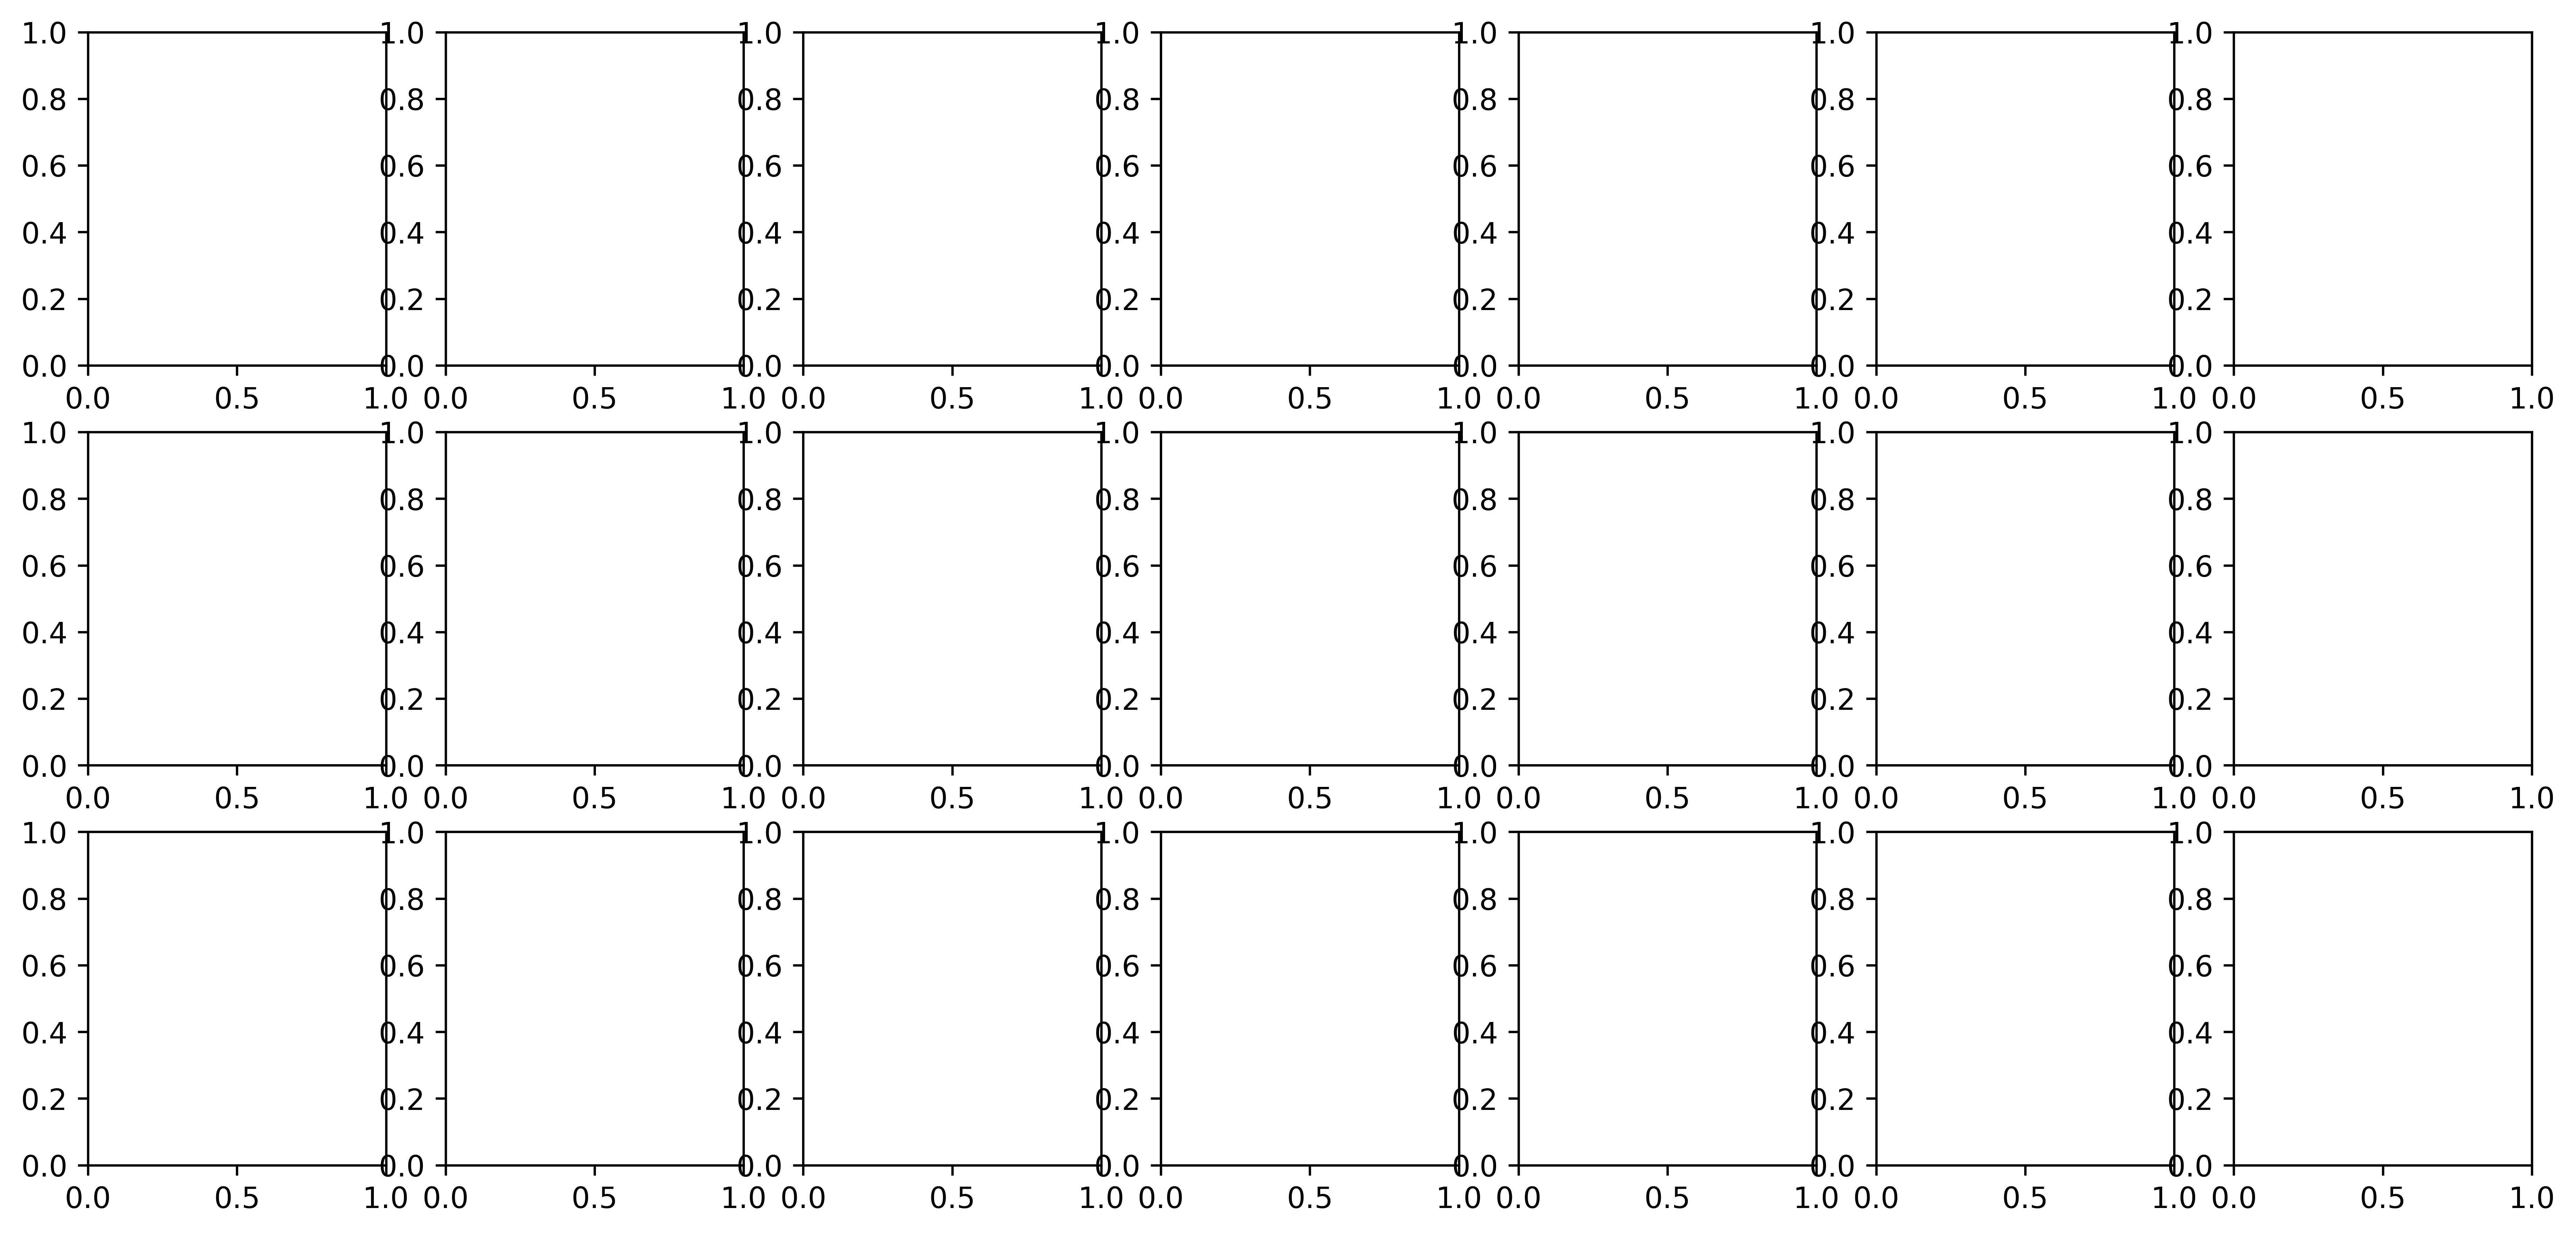

In [5]:
fig, axes = plt.subplots(3, 7, figsize=(15, 7), dpi=600)
axes = axes.ravel()

for ax, protein in zip(axes, PROTEINS):

    file = os.path.join(PATH_TO_OUTPUT, f"figure_{protein}.png")
    ax.imshow(mpimg.imread(file), interpolation='none', resample=False)
    ax.set_axis_off()
    title = f"{uniprot_to_gene[protein]}\n({protein})"
    ax.text(0.5, 1.00, title, transform=ax.transAxes, ha="center", va="top", fontsize=12, color="black", 
            bbox=dict(boxstyle="round,pad=0.2", alpha=0, edgecolor="none")
)

plt.tight_layout(pad=0)
plt.savefig(os.path.join(PATH_TO_OUTPUT, f"protein_structures.svg"), dpi=600)
plt.show()
plt.close(fig)